# Building a Fully Connected Neural Network for Devnagari Handwritten Digit Classification

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 0: Install / Check Dependencies

In [77]:
# Check TensorFlow and Keras versions
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [78]:
import zipfile
import os
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted.')

zip_file_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 4/devnagari digit.zip'

extract_to_path = '.'

if os.path.exists(zip_file_path):
    print(f'Found zip file: {zip_file_path}')
    print(f'Unzipping to: {os.path.abspath(extract_to_path)}...')
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_path)
    print('Unzipped!')
    os.system('ls -F')

    if os.path.isdir('DevanagariHandwrittenDigitDataset'):
        print('Dataset folder found.')
    else:
        print('Warning: Dataset folder not found after unzipping.')
else:
    print(f'Error: Zip file not found at {zip_file_path}')

Google Drive already mounted.
Found zip file: /content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 4/devnagari digit.zip
Unzipping to: /content...
Unzipped!
Dataset folder found.


## Task 1: Data Preparation

In [79]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print('All libraries imported successfully!')


All libraries imported successfully!


In [80]:
train_dir = 'DevanagariHandwrittenDigitDataset/Train/'
test_dir  = 'DevanagariHandwrittenDigitDataset/Test/'

img_height = 28
img_width  = 28

num_classes = 10

print('Dataset paths set:')
print('  Train:', train_dir)
print('  Test :', test_dir)


Dataset paths set:
  Train: DevanagariHandwrittenDigitDataset/Train/
  Test : DevanagariHandwrittenDigitDataset/Test/


In [81]:
def load_images_from_folder(folder):
    """
    Loads all images from a folder in required structure

    Returns:
        images : numpy array of shape (num_samples, 28, 28)
        labels : numpy array of shape (num_samples,) with integer labels
    """
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))

    class_map = {name: i for i, name in enumerate(class_names)}
    print(f'Classes found: {class_map}')

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path)
                img = img.convert('L')
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f'Skipping {img_path}: {e}')

    return np.array(images), np.array(labels)


In [82]:
print('Loading training data...')
x_train, y_train = load_images_from_folder(train_dir)

print('\nLoading test data...')
x_test, y_test = load_images_from_folder(test_dir)

print('\nRaw shapes:')
print(f'  x_train: {x_train.shape}')
print(f'  y_train: {y_train.shape}')
print(f'  x_test : {x_test.shape}')
print(f'  y_test : {y_test.shape}')


Loading training data...
Classes found: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading test data...
Classes found: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Raw shapes:
  x_train: (17000, 28, 28)
  y_train: (17000,)
  x_test : (3000, 28, 28)
  y_test : (3000,)


In [83]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1, img_height, img_width, 1)

print('After reshape:')
print(f'  x_train: {x_train.shape}')
print(f'  x_test : {x_test.shape}')


After reshape:
  x_train: (17000, 28, 28, 1)
  x_test : (3000, 28, 28, 1)


In [84]:
y_train_ohe = to_categorical(y_train, num_classes=num_classes)
y_test_ohe  = to_categorical(y_test,  num_classes=num_classes)

print('After one-hot encoding:')
print(f'  y_train: {y_train_ohe.shape}')
print(f'  y_test : {y_test_ohe.shape}')
print(f'\nExample: label {y_train[0]} → {y_train_ohe[0]}')

After one-hot encoding:
  y_train: (17000, 10)
  y_test : (3000, 10)

Example: label 0 → [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


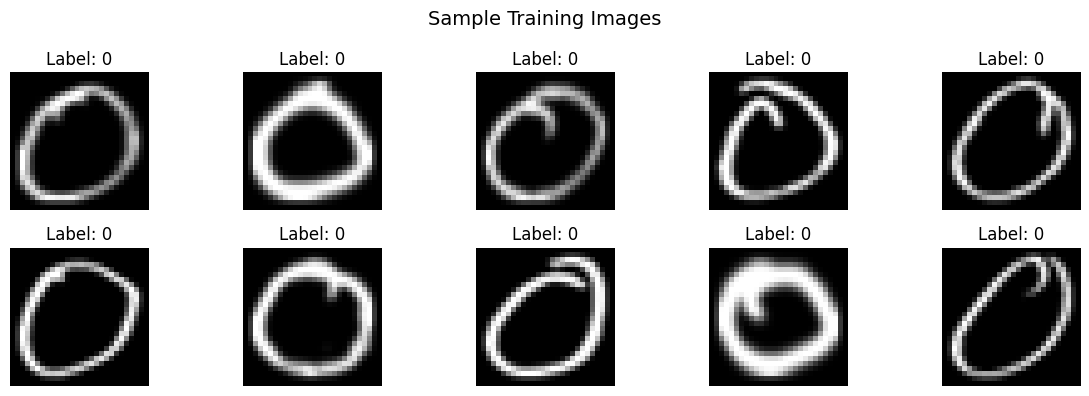

In [85]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train_ohe[i])}')
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## Task 2: Build the FCN Model

In [86]:
input_shape = (28, 28, 1)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),

    keras.layers.Dense(num_classes, activation='softmax'),
])

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [87]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print('Model compiled successfully!')
print('Optimizer : Adam')
print('Loss : Categorical Crossentropy')
print('Metric : Accuracy')

Model compiled successfully!
Optimizer : Adam
Loss : Categorical Crossentropy
Metric : Accuracy


## Task 4: Train the Model

In [88]:
batch_size = 128
epochs = 20

print(f'Batch size : {batch_size}')
print(f'Epochs : {epochs}')

Batch size : 128
Epochs : 20


In [89]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        verbose=1,
        restore_best_weights=True
    ),
]

print('Callbacks defined:')
print('  1. ModelCheckpoint → saves best model to best_devnagari_model.keras')
print('  2. EarlyStopping   → stops training if val_loss stalls for 4 epochs')


Callbacks defined:
  1. ModelCheckpoint → saves best model to best_devnagari_model.keras
  2. EarlyStopping   → stops training if val_loss stalls for 4 epochs


In [90]:
print('Training started\n')

history = model.fit(
    x_train,
    y_train_ohe,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Training started

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2440 - loss: 2.0000
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4340 - loss: 1.6471 - val_accuracy: 0.0000e+00 - val_loss: 6.7184
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8141 - loss: 0.6541
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8406 - loss: 0.5195 - val_accuracy: 0.0000e+00 - val_loss: 7.7637
Epoch 3/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9071 - loss: 0.3204
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9139 - loss: 0.2917 - val_accuracy: 0.0000e+00 - val_loss: 8.5498
Epoch 4/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9389 - loss: 0.2161
Epoch 4: val_ac

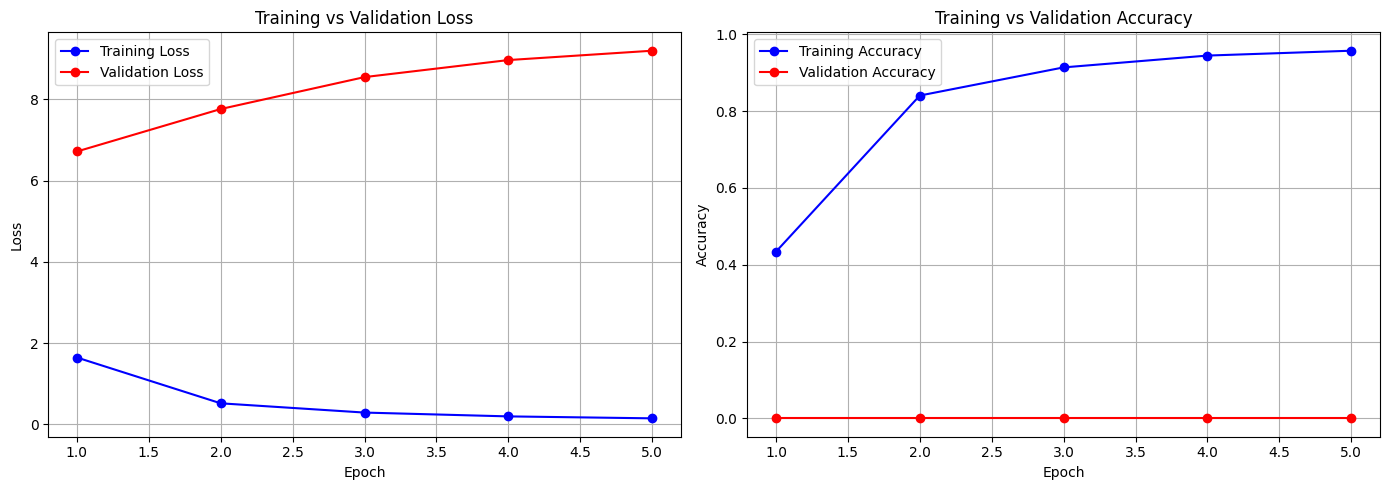

In [91]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# --- Plot 1: Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs_ran, val_loss,   'r-o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# --- Plot 2: Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, 'b-o', label='Training Accuracy')
plt.plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [92]:
print('Model evaluation on test set\n')

test_loss, test_acc = model.evaluate(
    x_test,        # Test images
    y_test_ohe,    # One-hot encoded test labels
    verbose=2      # Print one line per evaluation step
)

print(f'\n==============================')
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc * 100:.2f}%')
print(f'==============================')

Model evaluation on test set

94/94 - 0s - 3ms/step - accuracy: 0.6310 - loss: 2.0166

Test Loss : 2.0166
Test Accuracy : 63.10%


## Task 6: Save and Load the Model

In [93]:
save_path = 'devnagari_fcn_model.h5'

model.save(save_path)

print(f'Model saved to: {save_path}')

Model saved to: devnagari_fcn_model.h5


In [94]:
loaded_model = tf.keras.models.load_model(save_path)

print(f'Model loaded from: {save_path}')
print('\nLoaded model summary:')
loaded_model.summary()

Model loaded from: devnagari_fcn_model.h5

Loaded model summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [95]:
print('Loaded model re-evaluation on the test set\n')

loaded_loss, loaded_acc = loaded_model.evaluate(
    x_test,
    y_test_ohe,
    verbose=2
)

print(f'\n==============================')
print(f'Loaded Model Test Loss : {loaded_loss:.4f}')
print(f'Loaded Model Test Accuracy : {loaded_acc * 100:.2f}%')
print(f'==============================')
print('\nThe loaded model matches the original model. ')

Loaded model re-evaluation on the test set

94/94 - 1s - 9ms/step - accuracy: 0.6310 - loss: 2.0166

Loaded Model Test Loss : 2.0166
Loaded Model Test Accuracy : 63.10%

The loaded model matches the original model. 


In [96]:
from google.colab import files
files.download('devnagari_fcn_model.h5')
print('Model download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model download started!


## Task 7: Make Predictions

In [97]:
predictions = model.predict(x_test, verbose=0)

print(f'Predictions shape: {predictions.shape}')
print(f'\nExample: probabilities for first test image:')
print(np.round(predictions[0], 4))
print(f'Sum of probabilities: {predictions[0].sum():.4f}')

Predictions shape: (3000, 10)

Example: probabilities for first test image:
[5.371e-01 3.050e-02 4.000e-03 2.500e-03 2.130e-02 7.500e-03 3.530e-02
 3.607e-01 7.000e-04 4.000e-04]
Sum of probabilities: 1.0000


In [98]:
predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(y_test_ohe, axis=1)
print('Sample Predictions vs True Labels:')
print(f'{"Index":<8} {"Predicted":<12} {"True":<8} {"Correct?"}')
print('-' * 40)
for i in range(10):
    correct = '' if predicted_labels[i] == true_labels[i] else '✗'
    print(f'{i:<8} {predicted_labels[i]:<12} {true_labels[i]:<8} {correct}')

Sample Predictions vs True Labels:
Index    Predicted    True     Correct?
----------------------------------------
0        0            0        
1        0            0        
2        0            0        
3        0            0        
4        0            0        
5        0            0        
6        0            0        
7        0            0        
8        0            0        
9        0            0        


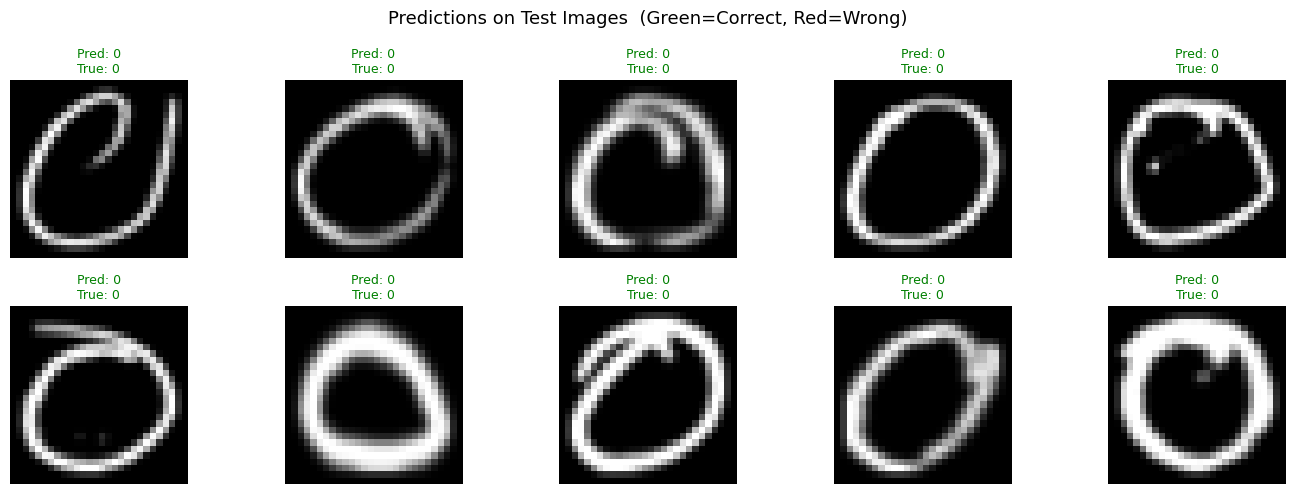

In [99]:
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    pred  = predicted_labels[i]
    true  = true_labels[i]
    color = 'green' if pred == true else 'red'

    plt.title(f'Pred: {pred}\nTrue: {true}', color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Predictions on Test Images  (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.show()

In [100]:
correct = np.sum(predicted_labels == true_labels)
total   = len(true_labels)
accuracy = correct / total * 100

print(f'Total test images : {total}')
print(f'Correct predictions: {correct}')
print(f'Wrong predictions  : {total - correct}')
print(f'\nOverall Test Accuracy: {accuracy:.2f}%')

Total test images : 3000
Correct predictions: 1893
Wrong predictions  : 1107

Overall Test Accuracy: 63.10%
